In [1]:
#import csv file
import pandas
get_csv_file = pandas.read_csv('Google_Stock_Dataset.csv')
get_csv_file

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,15.689439,15.753504,15.621622,15.684434,15.684434,78169752
1,2010-01-05,15.695195,15.711712,15.554054,15.615365,15.615365,120067812
2,2010-01-06,15.662162,15.662162,15.174174,15.221722,15.221722,158988852
3,2010-01-07,15.250250,15.265265,14.831081,14.867367,14.867367,256315428
4,2010-01-08,14.814815,15.096346,14.742492,15.065566,15.065566,188783028
...,...,...,...,...,...,...,...
3267,2022-12-23,87.110001,89.550003,87.070000,89.230003,89.230003,23003000
3268,2022-12-27,88.800003,88.940002,87.010002,87.389999,87.389999,20097300
3269,2022-12-28,86.980003,88.040001,85.940002,86.019997,86.019997,19523200
3270,2022-12-29,86.620003,88.849998,86.610001,88.449997,88.449997,23333500


In [2]:
#consider the close index only
stock_data = get_csv_file[['Date', 'Close']]
stock_data

,Date,Close
0,2010-01-04,15.684434
1,2010-01-05,15.615365
2,2010-01-06,15.221722
3,2010-01-07,14.867367
4,2010-01-08,15.065566
...,...,...
3267,2022-12-23,89.230003
3268,2022-12-27,87.389999
3269,2022-12-28,86.019997
3270,2022-12-29,88.449997


In [3]:
#function to convert date in string to date
import datetime
def str_to_date(s):
    split = s.split('-')
    year = int(split[0])
    month = int(split[1])
    day = int(split[2])
    return datetime.datetime(year=year, month=month, day=day)

#convert the data
stock_data['Date'] = stock_data['Date'].apply(str_to_date)
stock_data['Date']

C:\Users\pangj\AppData\Local\Temp\ipykernel_6888\3264878243.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Date'] = stock_data['Date'].apply(str_to_date)


0      2010-01-04
1      2010-01-05
2      2010-01-06
3      2010-01-07
4      2010-01-08
          ...    
3267   2022-12-23
3268   2022-12-27
3269   2022-12-28
3270   2022-12-29
3271   2022-12-30
Name: Date, Length: 3272, dtype: datetime64[ns]

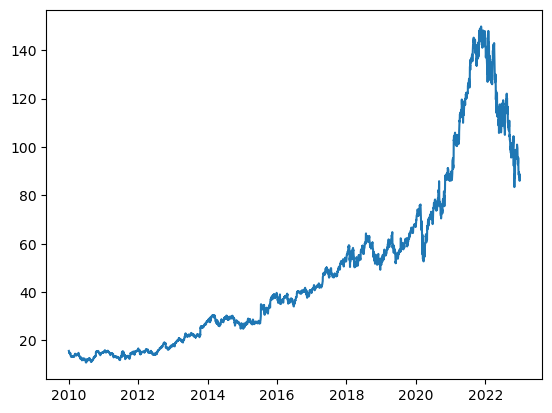

In [4]:
#set date as x-axis and close index as y-axis to plot a graph
stock_data.index = stock_data.pop('Date')

import matplotlib.pyplot
matplotlib.pyplot.plot(stock_data.index, stock_data['Close'])


In [5]:
#prepare data to make prediction
import numpy

def stock_data_to_windowed_stock_data(dataframe, str_first_date, str_last_date, n=3):
    first_date = str_to_date(str_first_date)
    last_date = str_to_date(str_last_date)
    
    current_date = first_date

    dates = []
    X, Y = [], [] 

    flag = False
    while True:
        stock_data_subset = dataframe.loc[:current_date].tail(n+1)
        if len(stock_data_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {current_date}')
            return
        
        values = stock_data_subset['Close'].to_numpy()
        x = values[:-1]
        y = values[-1]

        dates.append(current_date)
        X.append(x)
        Y.append(y)

        next_week = dataframe.loc[current_date:current_date+datetime.timedelta(days=7)]
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
        next_date_str = next_datetime_str.split('T')[0]
        year_month_day = next_date_str.split('-')
        year, month, day = year_month_day
        next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))

        if flag:
            break

        current_date = next_date

        if current_date == last_date:
            flag = True

    ret_stock_data = pandas.DataFrame({})
    ret_stock_data['Target Date'] = dates

    X = numpy.array(X)
    for i in range(0,n):
        X[:, i]
        ret_stock_data[f'Target-{n-i}'] = X[:, i]

    ret_stock_data['Target'] = Y
    return ret_stock_data

windowed_stock_data = stock_data_to_windowed_stock_data(stock_data, '2017-03-01', '2022-12-30', n=3)

windowed_stock_data


,Target Date,Target-3,Target-2,Target-1,Target
0,2017-03-01,42.390499,42.483501,42.246498,42.837502
1,2017-03-02,42.483501,42.246498,42.837502,42.492500
2,2017-03-03,42.246498,42.837502,42.492500,42.453999
3,2017-03-06,42.837502,42.492500,42.453999,42.363499
4,2017-03-07,42.492500,42.453999,42.363499,42.557499
...,...,...,...,...,...
1466,2022-12-23,89.019997,89.580002,87.760002,89.230003
1467,2022-12-27,89.580002,87.760002,89.230003,87.389999
1468,2022-12-28,87.760002,89.230003,87.389999,86.019997
1469,2022-12-29,89.230003,87.389999,86.019997,88.449997


In [6]:
def windowed_stock_data_to_date_X_Y(windowed_dataframe):
    stock_data_to_numpy = windowed_dataframe.to_numpy()

    dates = stock_data_to_numpy[:,0]
    middle_matrix = stock_data_to_numpy[:,1:-1]

    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = stock_data_to_numpy[:, -1]

    return dates, X.astype(numpy.float32), Y.astype(numpy.float32)

dates, X, Y, = windowed_stock_data_to_date_X_Y(windowed_stock_data)

dates.shape, X.shape, Y.shape

((1471,), (1471, 3, 1), (1471,))

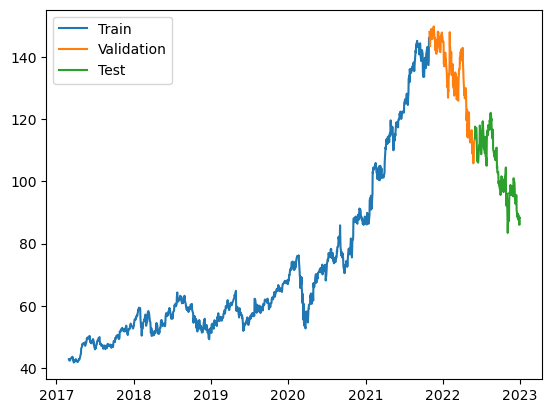

In [7]:
len_80p = int(len(dates) * .8) #80% of data
len_90p = int(len(dates) * .9) #90% of data

#slpit the data into 3 parts: train, validation and test
dates_train = dates[:len_80p]
X_train = X[:len_80p]
Y_train = Y[:len_80p]

dates_validation = dates[len_80p:len_90p]
X_validation = X[len_80p:len_90p]
Y_validation = Y[len_80p:len_90p]

dates_test = dates[len_90p:]
X_test = X[len_90p:]
Y_test = Y[len_90p:]

#plot graph
matplotlib.pyplot.plot(dates_train, Y_train)
matplotlib.pyplot.plot(dates_validation, Y_validation)
matplotlib.pyplot.plot(dates_test, Y_test)

matplotlib.pyplot.legend(['Train', 'Validation', 'Test'])

Datasets are processed and ready to be train. Tensorflow is the library that going be use to train the data.

In [8]:

#train data by using tensorflow library
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss = 'mse',
              optimizer = Adam(learning_rate=0.001),
              metrics = ['mean_absolute_error'])

model.fit(X_train, Y_train, validation_data=(X_validation, Y_validation), epochs=100)

Epoch 1/100
37/37 [==============================] - 3s 19ms/step - loss: 5363.2363 - mean_absolute_error: 68.5091 - val_loss: 17049.2168 - val_mean_absolute_error: 130.0529
Epoch 2/100
37/37 [==============================] - 0s 4ms/step - loss: 3783.7063 - mean_absolute_error: 54.9246 - val_loss: 10697.0693 - val_mean_absolute_error: 102.7448
Epoch 3/100
37/37 [==============================] - 0s 4ms/step - loss: 1007.9449 - mean_absolute_error: 22.5325 - val_loss: 3871.4792 - val_mean_absolute_error: 61.1305
Epoch 4/100
37/37 [==============================] - 0s 4ms/step - loss: 625.8135 - mean_absolute_error: 18.7379 - val_loss: 3670.2913 - val_mean_absolute_error: 59.5067
Epoch 5/100
37/37 [==============================] - 0s 8ms/step - loss: 337.5086 - mean_absolute_error: 11.7333 - val_loss: 1441.1224 - val_mean_absolute_error: 36.2748
Epoch 6/100
37/37 [==============================] - 0s 9ms/step - loss: 56.8773 - mean_absolute_error: 3.2780 - val_loss: 212.2096 - val_mean

37/37 [==============================] - 1s 1ms/step


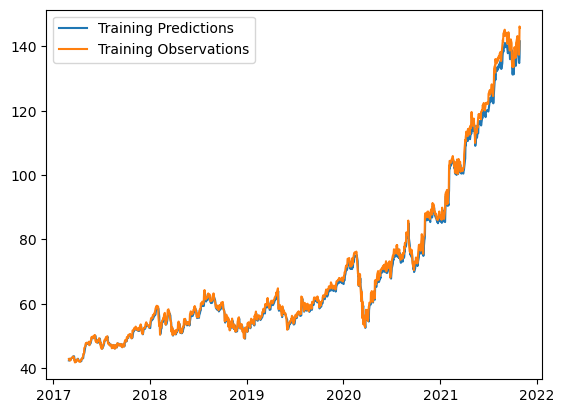

In [9]:
#make prediction base on training set
train_predictions = model.predict(X_train).flatten()

matplotlib.pyplot.plot(dates_train, train_predictions)
matplotlib.pyplot.plot(dates_train, Y_train)
matplotlib.pyplot.legend(['Training Predictions', 'Training Observations'])

5/5 [==============================] - 0s 2ms/step


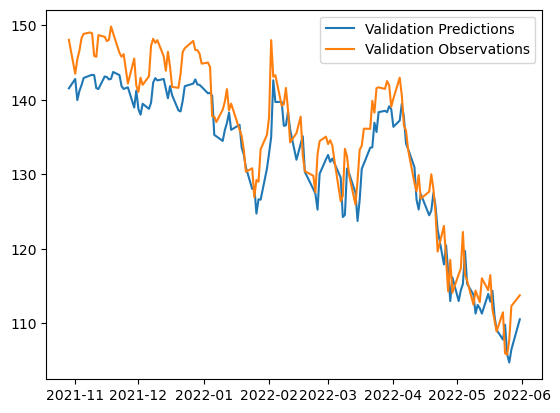

In [10]:
#do validation base on training set
val_predictions = model.predict(X_validation).flatten()

matplotlib.pyplot.plot(dates_validation, val_predictions)
matplotlib.pyplot.plot(dates_validation, Y_validation)
matplotlib.pyplot.legend(['Validation Predictions', 'Validation Observations'])

5/5 [==============================] - 0s 1ms/step


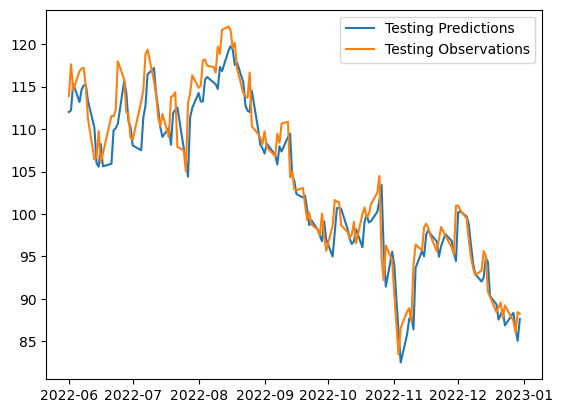

In [11]:
test_predictions = model.predict(X_test).flatten()

matplotlib.pyplot.plot(dates_test, test_predictions)
matplotlib.pyplot.plot(dates_test, Y_test)
matplotlib.pyplot.legend(['Testing Predictions', 'Testing Observations'])

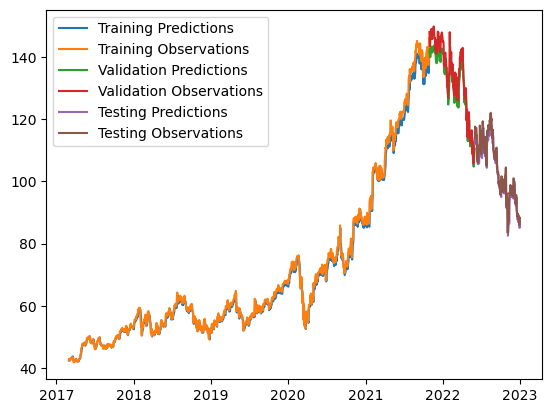

In [12]:
#3 graph above ploted in 1 graph
matplotlib.pyplot.plot(dates_train, train_predictions)
matplotlib.pyplot.plot(dates_train, Y_train)

matplotlib.pyplot.plot(dates_validation, val_predictions)
matplotlib.pyplot.plot(dates_validation, Y_validation)

matplotlib.pyplot.plot(dates_test, test_predictions)
matplotlib.pyplot.plot(dates_test, Y_test)

matplotlib.pyplot.legend(['Training Predictions', 'Training Observations',
                        'Validation Predictions', 'Validation Observations',
                        'Testing Predictions', 'Testing Observations'])

From the graph above, we can found that the prediction lines are overlapping with the observation line most of the time, which means that our model has done a good prediction. Next, we are going to let our model to make prediction for the future date.

In [13]:
#prepare data to make prediction
from copy import deepcopy

recursive_predictions = []
recursive_dates = numpy.concatenate([dates_validation, dates_test])
last_window = deepcopy(X_train[-1])
for current_date in recursive_dates:
  next_prediction = model.predict(numpy.array([last_window])).flatten()
  recursive_predictions.append(next_prediction)
  last_window = numpy.concatenate((last_window, [next_prediction]))


1/1 [==============================] - 0s 36ms/step


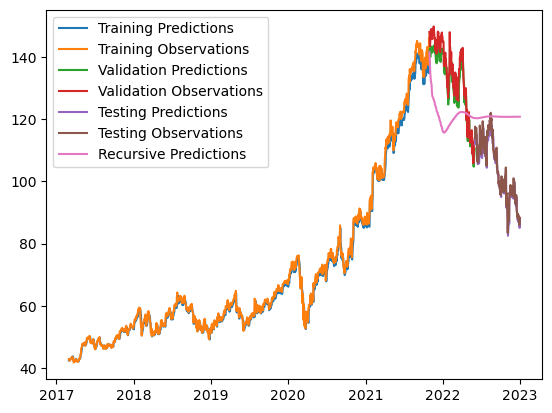

In [14]:
#plot recursive predictions graph together with training, validation a d test graph
matplotlib.pyplot.plot(dates_train, train_predictions)
matplotlib.pyplot.plot(dates_train, Y_train)

matplotlib.pyplot.plot(dates_validation, val_predictions)
matplotlib.pyplot.plot(dates_validation, Y_validation)

matplotlib.pyplot.plot(dates_test, test_predictions)
matplotlib.pyplot.plot(dates_test, Y_test)

matplotlib.pyplot.plot(recursive_dates, recursive_predictions)

matplotlib.pyplot.legend(['Training Predictions', 'Training Observations',
                        'Validation Predictions', 'Validation Observations',
                        'Testing Predictions', 'Testing Observations',
                        'Recursive Predictions'])